In [4]:
import pandas as pd
import numpy as np
import glob
from tqdm.auto import tqdm

import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import transforms
import pathlib
from torch.utils.data import DataLoader, TensorDataset
import torchvision
from torch.optim.lr_scheduler import ExponentialLR
from torchviz import make_dot

import pytorch_lightning as pl

import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib
from matplotlib.ticker import MaxNLocator

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
from torchmetrics.functional import accuracy

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

import datetime
import time
import random
import os


# setting device on GPU if available, else CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda:0

NVIDIA RTX A6000
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [5]:
class PW_Only_ConstWidth(nn.Module):
    """
    Pointwise-only block (constant width):
    PW 1x1 (C->C), NO depthwise.
    """
    def __init__(self, C=32, stride=1):
        super().__init__()
        self.pw = nn.Sequential(
            nn.Conv2d(C, C, kernel_size=1, stride=stride, padding=0, bias=False),  # 32 -> 32
            nn.BatchNorm2d(C),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.pw(x)


class MobileNetV1_ConstantWidth32_PWOnly(nn.Module):
    """
    Same as your constant-width model, but blocks are pointwise-only.
    Stem/strides/GAP/classifier remain the same.
    """
    def __init__(self, num_classes=10, in_channels=1, C=32, stem_stride=2):
        super().__init__()

        # Stem stays the same
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, C, kernel_size=3, stride=stem_stride, padding=1, bias=False),
            nn.BatchNorm2d(C),
            nn.ReLU(inplace=True),
        )

        # Same stride schedule
        strides = [1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1]

        # Replace DW+PW blocks with PW-only blocks
        self.features = nn.Sequential(*[PW_Only_ConstWidth(C=C, stride=s) for s in strides])

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(C, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [6]:
def load_train_test_loaders_from_npz(
    npz_path,
    batch_size=64,
    shuffle_train=True,
    seed=42,
    drop_last_train=True
):
    if not os.path.exists(npz_path):
        raise FileNotFoundError(f"NPZ not found: {os.path.abspath(npz_path)}")

    data = np.load(npz_path)
    required = {"X_train", "y_train", "X_test", "y_test"}
    if not required.issubset(set(data.files)):
        raise KeyError(f"NPZ must contain {sorted(required)}. Found: {data.files}")

    # Train tensors
    X_train = torch.from_numpy(data["X_train"]).float()
    y_train = torch.from_numpy(data["y_train"]).long()
    train_dataset = TensorDataset(X_train, y_train)

    # Test tensors
    X_test = torch.from_numpy(data["X_test"]).float()
    y_test = torch.from_numpy(data["y_test"]).long()
    test_dataset = TensorDataset(X_test, y_test)

    # Deterministic shuffle for train
    generator = None
    if shuffle_train:
        generator = torch.Generator()
        generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        generator=generator,
        drop_last=drop_last_train
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    return train_loader, test_loader

In [7]:
# usage
npz_path = "Prepared/Kia_human_train_test_chunks.npz"
train_loader, test_loader = load_train_test_loaders_from_npz(
    npz_path,
    batch_size=64,
    shuffle_train=True,
    seed=42
)

# sanity check
x_tr, y_tr = next(iter(train_loader))
x_te, y_te = next(iter(test_loader))
print("Train batch:", x_tr.shape, y_tr.shape)
print("Test  batch:", x_te.shape, y_te.shape)
print("Train labels unique (batch):", torch.unique(y_tr))
print("Test  labels unique (batch):", torch.unique(y_te))

Train batch: torch.Size([64, 1, 20, 10]) torch.Size([64])
Test  batch: torch.Size([64, 1, 20, 10]) torch.Size([64])
Train labels unique (batch): tensor([0, 1, 2, 3, 6, 7])
Test  labels unique (batch): tensor([ 0,  1,  2,  3,  7, 10])


In [8]:
model = MobileNetV1_ConstantWidth32_PWOnly(num_classes=11)

# Define the loss function (e.g., cross-entropy loss)
criterion = nn.CrossEntropyLoss()

# Choose an optimizer (e.g., Adam optimizer)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

# Set the device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

MobileNetV1_ConstantWidth32_PWOnly(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (features): Sequential(
    (0): PW_Only_ConstWidth(
      (pw): Sequential(
        (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): PW_Only_ConstWidth(
      (pw): Sequential(
        (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (2): PW_Only_ConstWidth(
      (pw): Sequential(
        (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentu

In [9]:
# Initialize variables for early stopping
best_val_loss = np.Inf
patience = 10  # Number of epochs to wait for improvement
counter = 0  # Counter for epochs without improvement
num_epochs = 150

# Move model to device
model.to(device)

train_dataset_len = len(train_loader.dataset)
test_dataset_len = len(test_loader.dataset)

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    
    # Training loop
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()  # Zero the parameter gradients
        
        outputs = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Compute the loss
        loss.backward()  # Backward pass
        optimizer.step()  # Optimize
        
        running_loss += loss.item() * inputs.size(0)  # Accumulate loss
    
    # Calculate average training loss for the epoch
    epoch_train_loss = running_loss / train_dataset_len
    
    # Validation loop
    model.eval()  # Set the model to evaluation mode
    running_val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for val_inputs, val_labels in test_loader:
            val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)
            running_val_loss += val_loss.item() * val_inputs.size(0)
            
            _, predicted = torch.max(val_outputs, 1)
            total += val_labels.size(0)
            correct += (predicted == val_labels).sum().item()
    
    # Calculate average validation loss and accuracy for the epoch
    epoch_val_loss = running_val_loss / test_dataset_len
    val_accuracy = correct / total
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.2%}")
    
    # Check for early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0  # Reset counter if validation loss improves
        # Save the model
        torch.save(model.state_dict(), "models/Kia_K_MobileNetV1ConsWidthOnlyPoint_20_Over_50.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping!")
            break

Epoch [1/150], Train Loss: 0.8624, Val Loss: 0.8240, Val Accuracy: 77.01%
Epoch [2/150], Train Loss: 0.8187, Val Loss: 0.8155, Val Accuracy: 77.70%
Epoch [3/150], Train Loss: 0.8031, Val Loss: 0.7955, Val Accuracy: 77.59%
Epoch [4/150], Train Loss: 0.7896, Val Loss: 0.7826, Val Accuracy: 78.02%
Epoch [5/150], Train Loss: 0.7805, Val Loss: 0.7680, Val Accuracy: 78.09%
Epoch [6/150], Train Loss: 0.7738, Val Loss: 0.7634, Val Accuracy: 78.11%
Epoch [7/150], Train Loss: 0.7695, Val Loss: 0.7690, Val Accuracy: 77.42%
Epoch [8/150], Train Loss: 0.7645, Val Loss: 0.7506, Val Accuracy: 78.23%
Epoch [9/150], Train Loss: 0.7607, Val Loss: 0.7503, Val Accuracy: 78.52%
Epoch [10/150], Train Loss: 0.7588, Val Loss: 0.7569, Val Accuracy: 78.46%
Epoch [11/150], Train Loss: 0.7548, Val Loss: 0.7738, Val Accuracy: 77.67%
Epoch [12/150], Train Loss: 0.7505, Val Loss: 0.7903, Val Accuracy: 78.62%
Epoch [13/150], Train Loss: 0.7501, Val Loss: 0.7491, Val Accuracy: 77.76%
Epoch [14/150], Train Loss: 0.7445

## Test Model

In [10]:
import torch
from sklearn.metrics import confusion_matrix
from src.MobileNetV1ConsWidthOnlyPoint import MobileNetV1_ConstantWidth32_PWOnly
from src.inference import LoadTestData, GetPrediction, GetProbsAndLabels
from src.metrics import PlotConfusionMatrixKia, ComputeFullMetrics, PlotPRCurve

In [13]:
# ---------- 4) Load model weights ----------
def LoadModel(ckpt_path, device, num_classes=11):
    model = MobileNetV1_ConstantWidth32_PWOnly(num_classes=num_classes)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    return model

In [15]:
# ---------- 5) Run prediction ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "models/Kia_K_MobileNetV1ConsWidthOnlyPoint_20_Over_50.pth"
npz_path = "Prepared/Kia_human_train_test_chunks.npz"
test_loader = LoadTestData(npz_path, batch_size=64)
model = LoadModel(ckpt_path, device=device, num_classes=11)

In [16]:
pred = GetPrediction(model, test_loader, device)
y_pred = pred[0]
y_test = pred[1]
cf_matrix = confusion_matrix(y_test, y_pred)

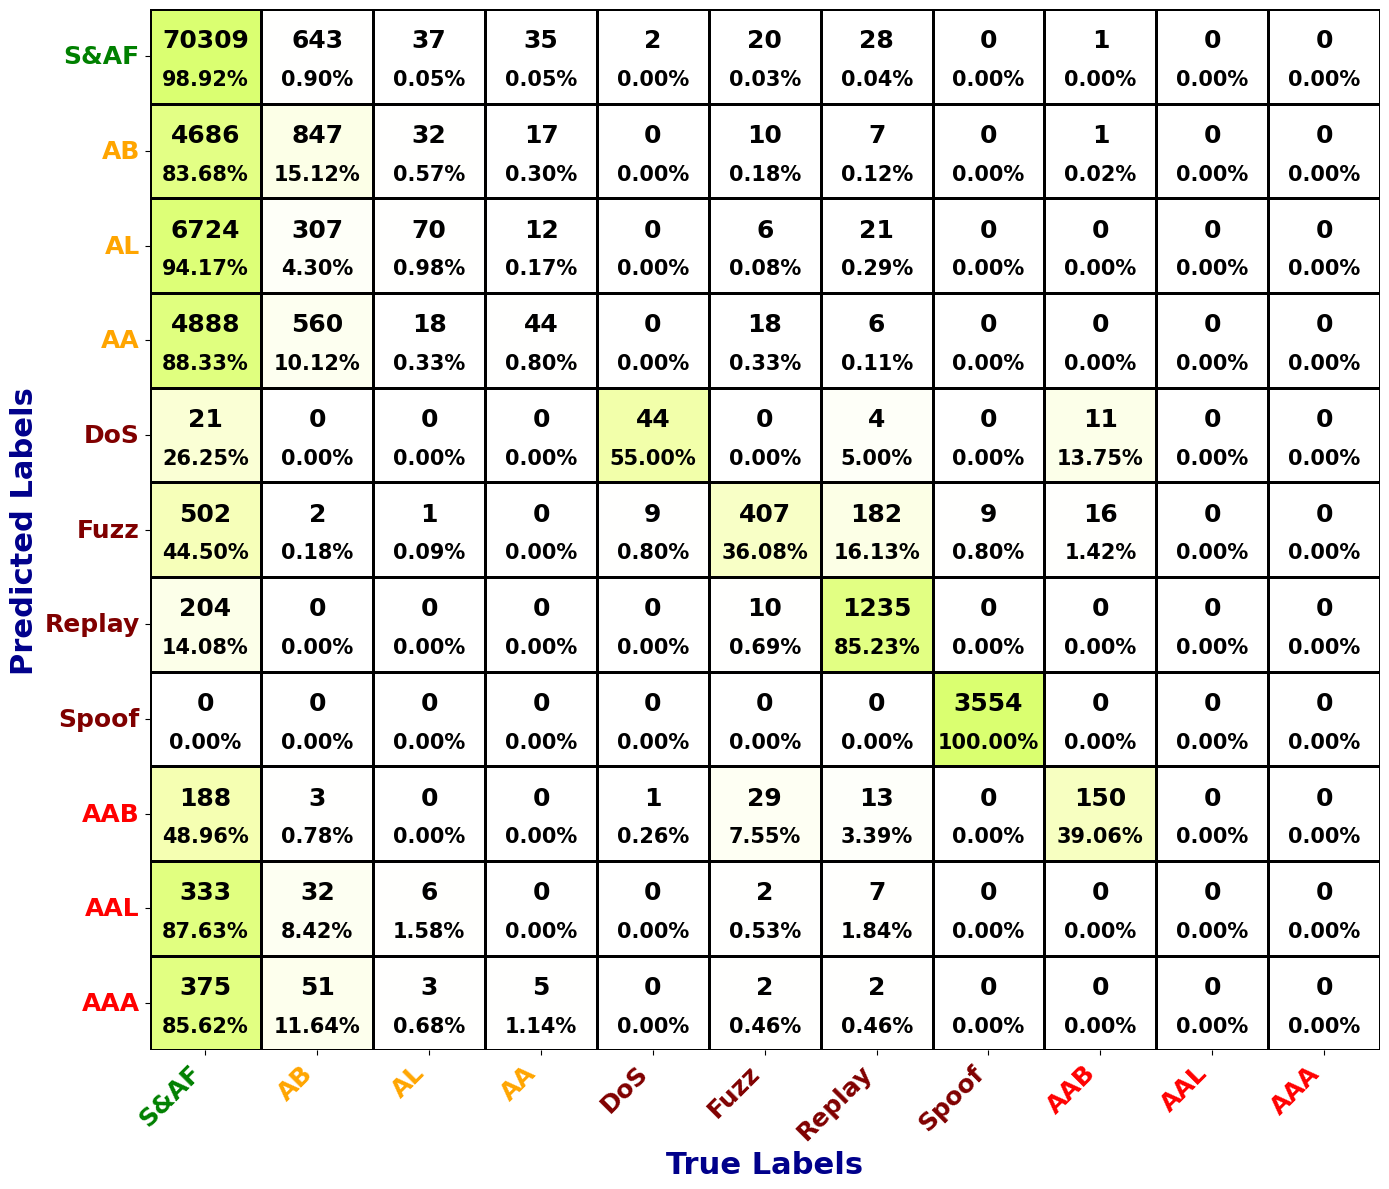

In [17]:
# --- Updated class labels --- #
class_labels = ["S&AF", "AB", "AL", "AA", "DoS", "Fuzz", "Replay", "Spoof", "AAB", "AAL", "AAA"]
PlotConfusionMatrixKia(cf_matrix, class_labels)

In [18]:
stats_df = ComputeFullMetrics(cf_matrix, class_labels)
stats_df

,Class,Support,Precision,Recall,F1,Accuracy,Error_Rate,CI_Lower,CI_Upper,AUC
0,S&AF,71075,0.7969,0.9892,0.8827,0.9892,0.0108,0.9884,0.9900,1.0000
1,AB,5600,0.3464,0.1512,0.2106,0.1512,0.8488,0.1421,0.1609,1.0000
2,AL,7140,0.4192,0.0098,0.0192,0.0098,0.9902,0.0078,0.0124,0.9958
3,AA,5534,0.3894,0.0080,0.0156,0.0080,0.9920,0.0059,0.0107,0.9952
4,DoS,80,0.7857,0.5500,0.6471,0.5500,0.4500,0.4412,0.6542,1.0000
5,Fuzz,1128,0.8075,0.3608,0.4988,0.3608,0.6392,0.3333,0.3893,1.0000
6,Replay,1449,0.8206,0.8523,0.8362,0.8523,0.1477,0.8331,0.8696,1.0000
7,Spoof,3554,0.9975,1.0000,0.9987,1.0000,0.0000,0.9989,1.0000,1.0000
8,AAB,384,0.8380,0.3906,0.5329,0.3906,0.6094,0.3431,0.4403,1.0000
9,AAL,380,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0100,0.5000


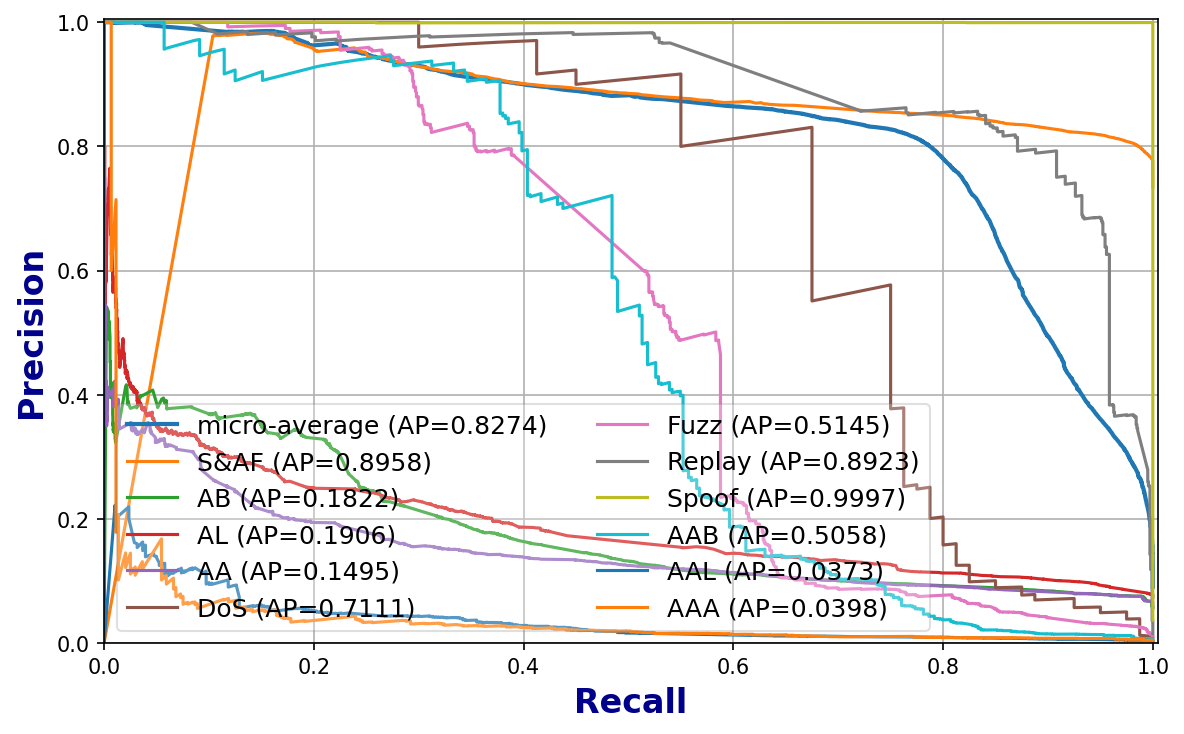

{'AP_micro': 0.8273780832445119,
 'AP_macro': 0.4653266638136389,
 'AP_per_class': {'S&AF': 0.8958266177413161,
  'AB': 0.18222570339867572,
  'AL': 0.19055637266799566,
  'AA': 0.14950929290315923,
  'DoS': 0.7111277513393369,
  'Fuzz': 0.5144761494801038,
  'Replay': 0.8923056884708984,
  'Spoof': 0.9996643152572325,
  'AAB': 0.5058100552938178,
  'AAL': 0.0372520663919714,
  'AAA': 0.039839289005520376}}

In [22]:
y_test, y_score = GetProbsAndLabels(model, test_loader, device)
PlotPRCurve(
    y_true=y_test,
    y_score=y_score,
    class_labels=["S&AF","AB","AL","AA","DoS","Fuzz","Replay","Spoof", "AAB","AAL","AAA"],
    xlim=(0.0, 1.005),
    ylim=(0.0, 1.005),
)

In [23]:
def count_parameters(model, trainable_only=True):
    if trainable_only:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

params = count_parameters(model, trainable_only=True)
print(f"Trainable params: {params:,}")
print(f"Model size (fp32): {params*4/1024/1024:.2f} MB")

Trainable params: 14,859
Model size (fp32): 0.06 MB
